Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


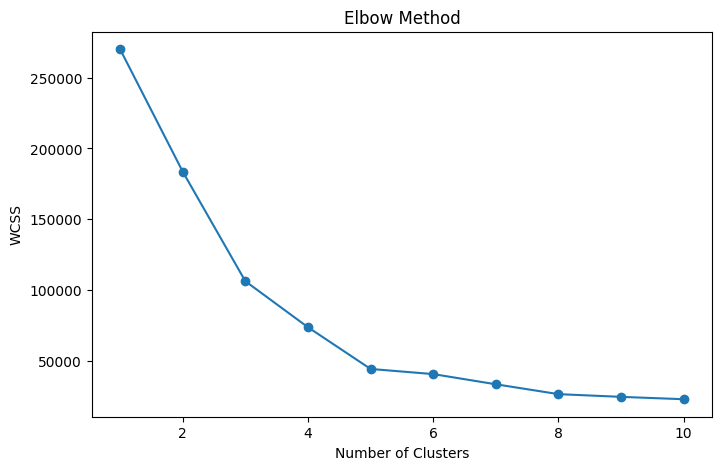

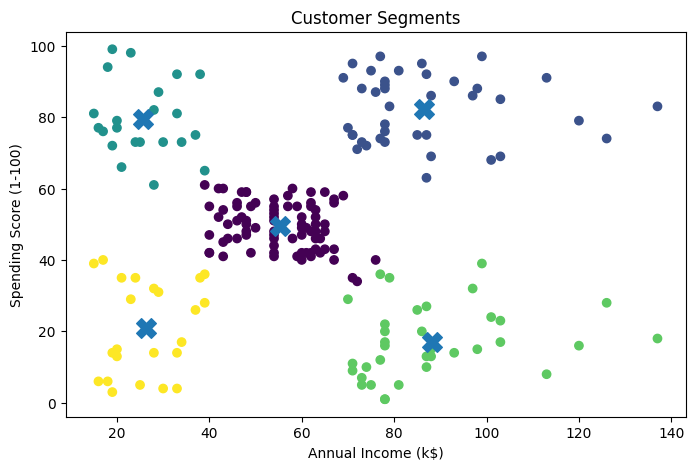

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.cluster import KMeans

# Mount Google Drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv(
    '/content/drive/MyDrive/internship_csv_files/Mall_Customers.csv'
)

# Display dataset
print(df.head())

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))

plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

# Apply K-Means with optimal K
kmeans = KMeans(n_clusters=5, random_state=42)

y_kmeans = kmeans.fit_predict(X)

# Plot clusters
plt.figure(figsize=(8,5))

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=y_kmeans
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker='X'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.title('Customer Segments')

plt.show()

## Insights

The Elbow Method indicated that K = 5 is the optimal number of clusters for this dataset.  
The K-Means algorithm successfully grouped customers based on annual income and spending score patterns.  
Some customers showed high income with high spending behavior, while others had high income but low spending habits.  
The clustering results can help businesses understand customer behavior and create targeted marketing strategies.  
Customer segmentation improves decision-making for promotions, product recommendations, and customer engagement.